# MNIST MeanFlow Experiment Visualization

This notebook visualizes the results of a MeanFlow training experiment on MNIST.
It loads the training logs, plots loss curves, displays generated samples, and shows evaluation metrics (NLL/BPD).

In [1]:
# --- Configuration ---
# Set your experiment name here (folder name inside 'results/')
# EXP_NAME = "baseline_Dec_06-21_18"  # batch_size=32
EXP_NAME = "baseline_Dec_07-13_21"  # batch_size=32, gradient_accumulation_steps=4
# EXP_NAME = "t_uniform_r_lognorm_instant_prob_45_resample"

# evaluation file name (default: evaluation_results.txt)
# EVAL_NAME = "evaluation_results.txt"
EVAL_NAME = "evaluation_results_100.txt"

import os
import subprocess
from vis_utils import plot_training_curves, show_eval_results, show_generated_samples

# Paths
exp_dir = os.path.join("results", EXP_NAME)
log_file = os.path.join(exp_dir, "log.txt")
images_dir = os.path.join(exp_dir, "images")
eval_results_file = os.path.join(exp_dir, EVAL_NAME)

print(f"Visualizing Experiment: {EXP_NAME}")
print(f"Directory: {exp_dir}")

Visualizing Experiment: baseline_Dec_07-13_21
Directory: results/baseline_Dec_07-13_21


## 1. Training Loss Curves

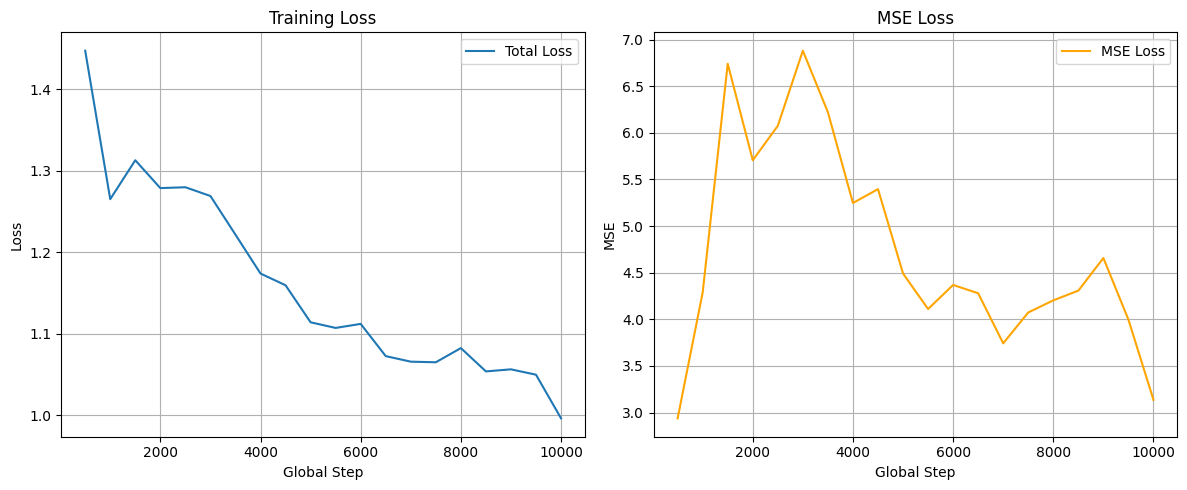

In [2]:
plot_training_curves(log_file)

## 2. Evaluation Metrics (NLL & BPD)

BPD = 8 bit/dim: Just generating random noise. 
BPD < 4 bit/dim: Generating something good
BPD = 3 ~ 3.3 bit/dim: Baseline MeanFlow (?)
BPD = 1~2 bit/dim: state-of-the-art flow matching/diffusion

Evaluation Results:


,Step,NLL,BPD
0,1000,2577.6941,3.6317
1,2000,2437.7952,3.4346
2,3000,2426.8044,3.4191
3,4000,2413.0144,3.3997
4,5000,2226.1345,3.1364
5,6000,2326.7590,3.2781
6,7000,2289.1609,3.2252
7,8000,2196.8904,3.0952
8,9000,2186.3774,3.0803
9,10000,2298.2834,3.2380


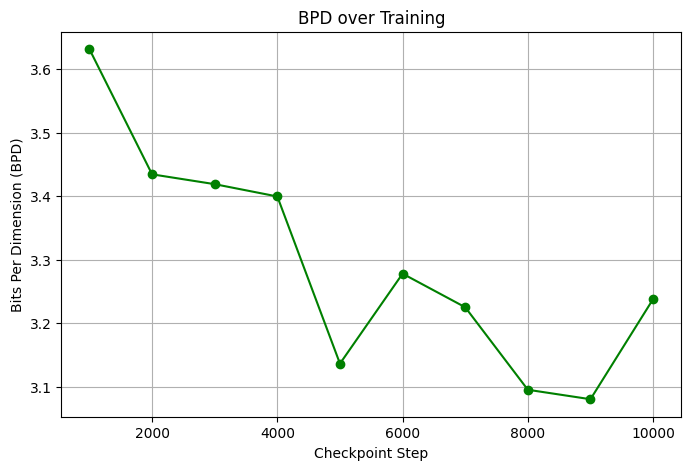

In [3]:
# Evaluate on only the last checkpoint
# show_eval_results(eval_results_file, EXP_NAME, limit_batches=1)

# Evaluate on a specific checkpoint
# show_eval_results(eval_results_file, EXP_NAME, ckpt_step=1000, limit_batches=1)

# Evaluate on ALL checkpoints (very expensive!)
show_eval_results(eval_results_file, EXP_NAME, show_all=True, limit_batches=1)

## 3. Generated Samples

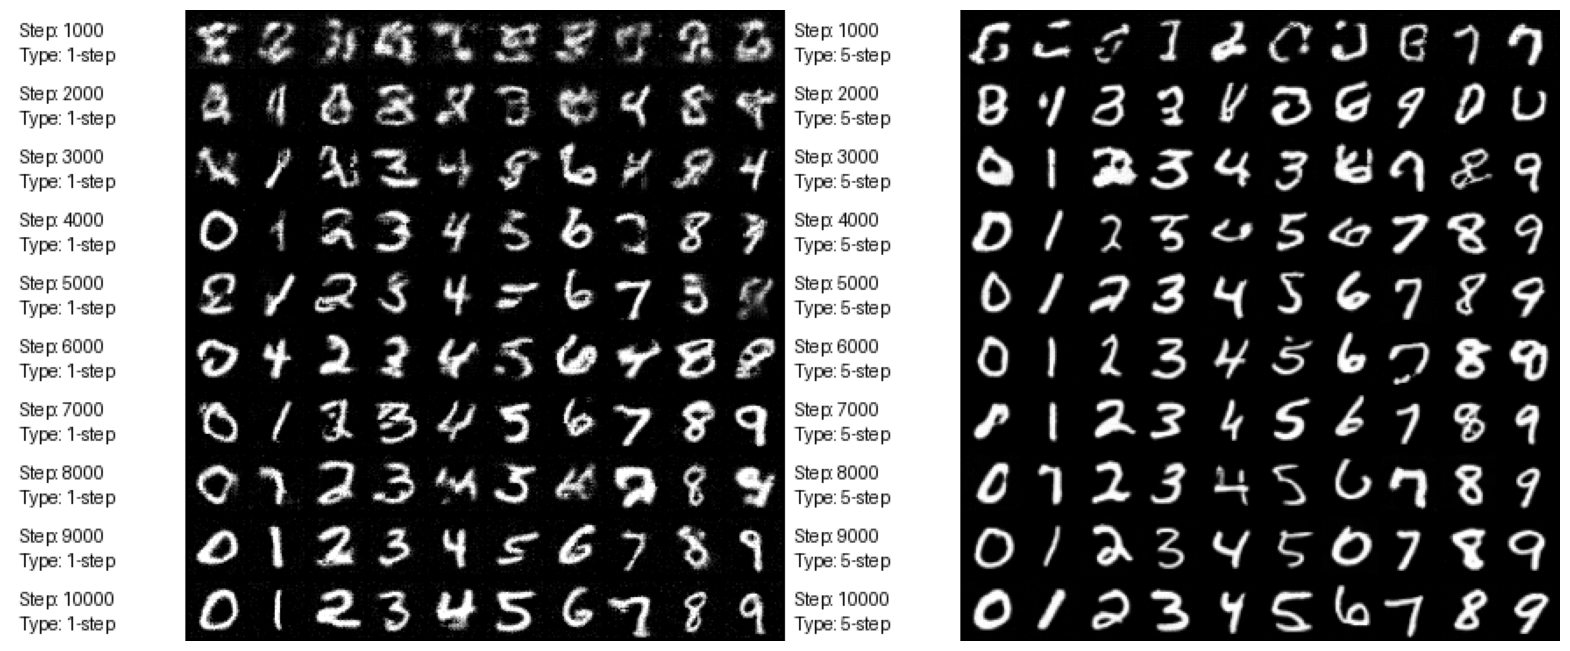

In [4]:
show_generated_samples(images_dir)